# Modeling

Baseline + modèle avancé, PR/ROC, calibration, choix de seuil.

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(ROOT / 'src'))

import json

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve

from models.evaluate import evaluate
from models.train import train_models
from utils.config import ARTIFACTS_DIR


In [3]:
ROOT = Path.cwd().resolve().parents[0]
train_path = ROOT / 'data/processed/train.parquet'
val_path = ROOT / 'data/processed/val.parquet'
test_path = ROOT / 'data/processed/test.parquet'
artifacts = train_models(train_path, val_path)



/home/narcisse/Projets/detecter-fraude-bancaire/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[LightGBM] [Info] Number of positive: 14, number of negative: 685
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7233
[LightGBM] [Info] Number of data points in the train set: 699, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [4]:

train_df = pd.read_parquet(train_path)
val_df = pd.read_parquet(val_path)
X_train, y_train = train_df.drop(columns=['Class']), train_df['Class']
X_val, y_val = val_df.drop(columns=['Class']), val_df['Class']


In [5]:
baseline = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
baseline.fit(X_train, y_train)
base_probs = baseline.predict_proba(X_val)[:, 1]


/home/narcisse/Projets/detecter-fraude-bancaire/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [6]:
import joblib

model = joblib.load(ARTIFACTS_DIR / 'model.joblib')
adv_probs = model.predict_proba(X_val)[:, 1]


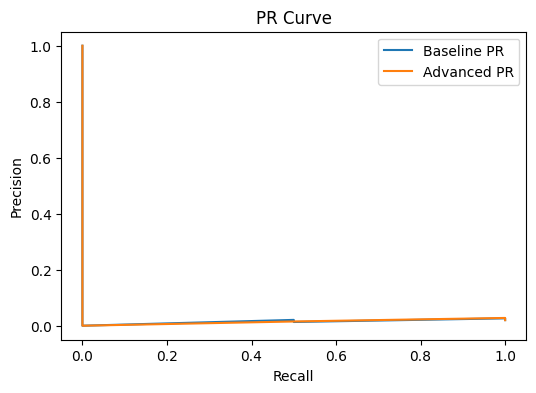

In [7]:
prec_b, rec_b, _ = precision_recall_curve(y_val, base_probs)
prec_a, rec_a, _ = precision_recall_curve(y_val, adv_probs)
plt.figure(figsize=(6,4))
plt.plot(rec_b, prec_b, label='Baseline PR')
plt.plot(rec_a, prec_a, label='Advanced PR')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve')
plt.legend()
plt.show()


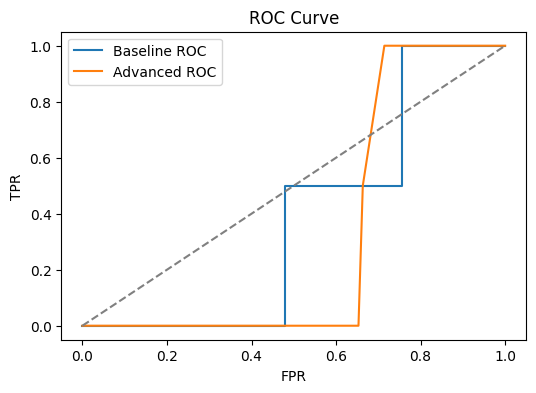

In [8]:
fpr_b, tpr_b, _ = roc_curve(y_val, base_probs)
fpr_a, tpr_a, _ = roc_curve(y_val, adv_probs)
plt.figure(figsize=(6,4))
plt.plot(fpr_b, tpr_b, label='Baseline ROC')
plt.plot(fpr_a, tpr_a, label='Advanced ROC')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()


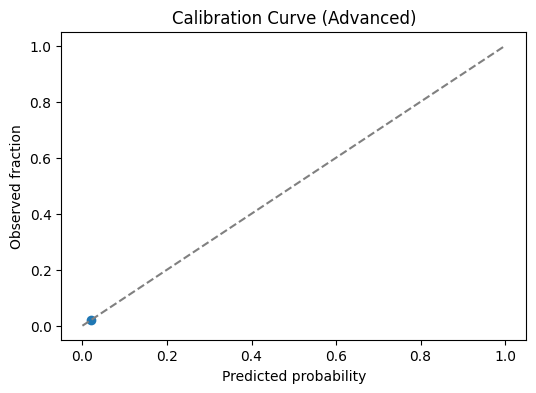

In [9]:
prob_true, prob_pred = calibration_curve(y_val, adv_probs, n_bins=10)
plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('Observed fraction')
plt.title('Calibration Curve (Advanced)')
plt.show()


In [10]:
metrics = evaluate(ARTIFACTS_DIR / 'model.joblib', test_path, ARTIFACTS_DIR / 'threshold.json')
metrics


{'pr_auc': 0.017468009420014103,
 'roc_auc': 0.3426395939086295,
 'precision': 0.015151515151515152,
 'recall': 0.5,
 'threshold': 0.015682823916846764,
 'tn': 67,
 'fp': 130,
 'fn': 2,
 'tp': 2}

In [11]:
threshold = json.loads((ARTIFACTS_DIR / 'threshold.json').read_text())['threshold']
threshold


0.015682823916846764

## Conclusions

- La PR-AUC est la métrique prioritaire compte tenu du déséquilibre.
- Calibration isotonic appliquée pour des probabilités fiables.
- Seuil choisi via F1 max sur validation; ajuster selon le coût métier FP/FN.